# Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import matplotlib.dates as mdates

# Functions

In [2]:
# def process_LABgauge_precipitation_data(file_path, interval_minutes=10):
    
#     """
#     Processes LAB gauge precipitation data.

#     Parameters:
#     - file_path (str): Path to the CSV file containing the data.
#     - interval_minutes (int, optional) only 5 or 10: Resampling interval in minutes (default is 10).

#     Returns:
#     - pd.DataFrame: Processed DataFrame with columns: 'Date Time', 'Cumulative Rain (mm)', 'Rain (mm)', 'Rain Intensity (mm/hr)'.
#     """

#     # Check if the interval_minutes parameter is valid (either 5 or 10)
#     if interval_minutes not in [5, 10]:
#         raise ValueError("Interval must be either 5 or 10 minutes.")

#     # Read the CSV file into a DataFrame
#     df = pd.read_csv(file_path, parse_dates=['Date Time'], dayfirst=True)
#     df.set_index('Date Time', inplace=True)

#     # Set a default value for 'Rain (mm)'
#     df['Rain (mm)'] = 0.1

#     # Resample the data to specified interval and fill missing values with 0.0
#     interval_str = f'{interval_minutes}T'
#     df_resampled = df.resample(interval_str).sum().fillna(0.0)

#     # Round the 'Date Time' column to the nearest specified interval
#     df_resampled['Date Time'] = df_resampled.index.round(interval_str)

#     # Format 'Date Time' column
#     df_resampled['Date Time'] = df_resampled['Date Time'].dt.strftime('%d/%m/%Y %H:%M')

#     # Add cumulative rain column
#     df_resampled['Cumulative Rain (mm)'] = df_resampled['Rain (mm)'].cumsum()

#     # Calculate rain intensity in mm/hr based on the interval
#     if interval_minutes == 10:
#         df_resampled['Rain Intensity (mm/hr)'] = df_resampled['Rain (mm)'] * 6
#     elif interval_minutes == 5:
#         df_resampled['Rain Intensity (mm/hr)'] = df_resampled['Rain (mm)'] * 12

#     # Keep only necessary columns
#     df_resampled = df_resampled[['Date Time', 'Cumulative Rain (mm)', 'Rain (mm)', 'Rain Intensity (mm/hr)']]

#     # Reset index and return the processed DataFrame
#     df_resampled.reset_index(drop=True, inplace=True)
#     return df_resampled

# def process_IMSgauge_precipitation_data(file_path):
#     """
#     Processes IMS gauge precipitation data.

#     Parameters:
#     - file_path (str): Path to the CSV file containing the data.

#     Returns:
#     - pd.DataFrame: Processed DataFrame with columns: 'Date Time', 'Cumulative Rain (mm)', 'Rain (mm)', 'Rain Intensity (mm/hr)'.
#     """

#     rain_df = pd.read_csv(file_path, parse_dates=['Date Time'], dayfirst=True)
#     # Format 'Date Time' column
#     rain_df['Date Time'] = rain_df['Date Time'].dt.strftime('%d/%m/%Y %H:%M')

#     # Add cumulative rain column
#     rain_df['Cumulative Rain (mm)'] = rain_df['Rain (mm)'].cumsum()

#     # Calculate rain intensity in mm/hr
#     rain_df['Rain Intensity (mm/hr)'] = rain_df['Rain (mm)'] * 6

#     rain_df = rain_df[['Date Time', 'Cumulative Rain (mm)', 'Rain (mm)', 'Rain Intensity (mm/hr)']]
#     return rain_df

# def plot_rain_intensity(rain_dfs, start_date, end_date):
    
#     """
#     Plots rain intensity for multiple DataFrames within a specified date range.

#     Parameters:
#     - rain_dfs (list): List of DataFrames containing precipitation data.
#     - start_date (str): Start date for plotting.
#     - end_date (str): End date for plotting.

#     Returns:
#     - None. Displays a plot of rain intensity over time.

#     Note: Ensure each DataFrame in `rain_dfs` has a 'name' attribute for proper legend labeling.
#     """

#     # Filter data based on the specified date range for each dataframe
#     filtered_dfs = [rain_df[(rain_df['Date Time'] >= start_date) & (rain_df['Date Time'] <= end_date)] for rain_df in rain_dfs]

#     # Plotting
#     plt.figure(figsize=(12, 6))

#     for i, rain_df in enumerate(filtered_dfs):
#         plt.plot(rain_df['Date Time'], rain_df['Rain Intensity (mm/hr)'], label=f'{rain_dfs[i].name}')

#     # Customize the plot
#     plt.title('Rain Intensity (mm/hr)')
#     plt.xlabel('Date Time')
#     plt.ylabel('Rain Intensity (mm/hr)')
#     plt.legend()
#     plt.grid(True)

#     # Set parameters for tick labels
#     plt.tick_params(axis='x', which='major', labelsize=12)
#     plt.xticks(filtered_dfs[0]['Date Time'].iloc[::12], rotation=45)

#     # Set y-axis minimum limit to 0
#     plt.ylim(0)

#     # Set x-axis minimum limit to the first date in the data
#     plt.xlim(filtered_dfs[0]['Date Time'].iloc[0], end_date)

#     # Show the plot
#     plt.tight_layout()
#     plt.show()
    
    
    



In [3]:
import pandas as pd

def process_LABgauge_precipitation_data(file_path, interval_minutes=10):
    """
    Processes LAB gauge precipitation data.

    Parameters:
    - file_path (str): Path to the CSV file containing the data.
    - interval_minutes (int, optional) only 5 or 10: Resampling interval in minutes (default is 10).

    Returns:
    - pd.DataFrame: Processed DataFrame with columns: 'Date Time', 'Cumulative Rain (mm)', 'Rain (mm)', 'Rain Intensity (mm/hr)'.
    """

    # Check if the interval_minutes parameter is valid (either 5 or 10)
    if interval_minutes not in [5, 10]:
        raise ValueError("Interval must be either 5 or 10 minutes.")

    # Read the CSV file into a DataFrame
    df = pd.read_csv(file_path, parse_dates=['Date Time'], dayfirst=True)
    df.set_index('Date Time', inplace=True)

    # Set a default value for 'Rain (mm)'
    df['Rain (mm)'] = 0.1

    # Resample the data to specified interval and fill missing values with 0.0
    interval_str = f'{interval_minutes}T'
    df_resampled = df.resample(interval_str).sum().fillna(0.0)

    # Round the 'Date Time' column to the nearest specified interval
    df_resampled['Date Time'] = pd.to_datetime(df_resampled.index.round(interval_str))


    # Add cumulative rain column
    df_resampled['Cumulative Rain (mm)'] = df_resampled['Rain (mm)'].cumsum()

    # Calculate rain intensity in mm/hr based on the interval
    if interval_minutes == 10:
        df_resampled['Rain Intensity (mm/hr)'] = df_resampled['Rain (mm)'] * 6
    elif interval_minutes == 5:
        df_resampled['Rain Intensity (mm/hr)'] = df_resampled['Rain (mm)'] * 12

    # Keep only necessary columns
    df_resampled = df_resampled[['Date Time', 'Cumulative Rain (mm)', 'Rain (mm)', 'Rain Intensity (mm/hr)']]

    # Reset index and return the processed DataFrame
    df_resampled.reset_index(drop=True, inplace=True)
    return df_resampled

def process_IMSgauge_precipitation_data(file_path):
    """
    Processes IMS gauge precipitation data.

    Parameters:
    - file_path (str): Path to the CSV file containing the data.

    Returns:
    - pd.DataFrame: Processed DataFrame with columns: 'Date Time', 'Cumulative Rain (mm)', 'Rain (mm)', 'Rain Intensity (mm/hr)'.
    """

    rain_df = pd.read_csv(file_path, parse_dates=['Date Time'], dayfirst=True)

    # Add cumulative rain column
    rain_df['Cumulative Rain (mm)'] = rain_df['Rain (mm)'].cumsum()

    # Calculate rain intensity in mm/hr
    rain_df['Rain Intensity (mm/hr)'] = rain_df['Rain (mm)'] * 6

    rain_df = rain_df[['Date Time', 'Cumulative Rain (mm)', 'Rain (mm)', 'Rain Intensity (mm/hr)']]
    return rain_df

def process_IMSgauge_precipitation_data(file_path):
    """
    Processes IMS gauge precipitation data.

    Parameters:
    - file_path (str): Path to the CSV file containing the data.

    Returns:
    - pd.DataFrame: Processed DataFrame with columns: 'Date Time', 'Cumulative Rain (mm)', 'Rain (mm)', 'Rain Intensity (mm/hr)'.
    """

    rain_df = pd.read_csv(file_path, parse_dates=['Date Time'], dayfirst=True)
    # Format 'Date Time' column
    rain_df['Date Time'] = pd.to_datetime(rain_df['Date Time'], format='%d/%m/%Y %H:%M')


    # Add cumulative rain column
    rain_df['Cumulative Rain (mm)'] = rain_df['Rain (mm)'].cumsum()

    # Calculate rain intensity in mm/hr
    rain_df['Rain Intensity (mm/hr)'] = rain_df['Rain (mm)'] * 6

    rain_df = rain_df[['Date Time', 'Cumulative Rain (mm)', 'Rain (mm)', 'Rain Intensity (mm/hr)']]
    return rain_df

def plot_rain_intensity(rain_dfs, start_date, end_date):
    
    """
    Plots rain intensity for multiple DataFrames within a specified date range.

    Parameters:
    - rain_dfs (list): List of DataFrames containing precipitation data.
    - start_date (str): Start date for plotting.
    - end_date (str): End date for plotting.

    Returns:
    - None. Displays a plot of rain intensity over time.

    Note: Ensure each DataFrame in `rain_dfs` has a 'name' attribute for proper legend labeling.
    """
    # Convert start_date and end_date to datetime objects
    start_date = datetime.strptime(start_date, '%d/%m/%Y %H:%M')
    end_date = datetime.strptime(end_date, '%d/%m/%Y %H:%M')
    
    # Filter data based on the specified date range for each dataframe
    filtered_dfs = [rain_df[(rain_df['Date Time'] >= start_date) & (rain_df['Date Time'] <= end_date)] for rain_df in rain_dfs]

    # Plotting
    plt.figure(figsize=(12, 6))

    for i, rain_df in enumerate(filtered_dfs):
        plt.plot(rain_df['Date Time'], rain_df['Rain Intensity (mm/hr)'], label=f'{rain_dfs[i].name}')

    # Customize the plot
    plt.title('Rain Intensity (mm/hr)')
    plt.xlabel('Date Time')
    plt.ylabel('Rain Intensity (mm/hr)')
    plt.legend()
    plt.grid(True)
    
    # Calculate the number of time steps and set the variable
    num_ticks = 10

    # Set parameters for tick labels
    plt.tick_params(axis='x', which='major', labelsize=12)
    plt.xticks(filtered_dfs[0]['Date Time'].iloc[::len(filtered_dfs[0]) // num_ticks], rotation=45)
    
    # Use DateFormatter to format the date and time on the x-axis ticks
    date_format = mdates.DateFormatter('%d/%m/%Y %H')
    plt.gca().xaxis.set_major_formatter(date_format)
    
    # Set y-axis minimum limit to 0
    plt.ylim(0)

    # Set x-axis minimum limit to the first date in the data
    plt.xlim(filtered_dfs[0]['Date Time'].iloc[0], end_date)

    # Show the plot
    plt.tight_layout()
    plt.show()
    
    
    
def plot_cumulative_rain(rain_dfs, start_date, end_date):
        
    """
    Plots rain intensity for multiple DataFrames within a specified date range.

    Parameters:
    - rain_dfs (list): List of DataFrames containing precipitation data.
    - start_date (str): Start date for plotting.
    - end_date (str): End date for plotting.

    Returns:
    - None. Displays a plot of rain intensity over time.

    Note: Ensure each DataFrame in `rain_dfs` has a 'name' attribute for proper legend labeling.
    """
    # Convert start_date and end_date to datetime objects
    start_date = datetime.strptime(start_date, '%d/%m/%Y %H:%M')
    end_date = datetime.strptime(end_date, '%d/%m/%Y %H:%M')
    
    # Filter data based on the specified date range for each dataframe
    filtered_dfs = [rain_df[(rain_df['Date Time'] >= start_date) & (rain_df['Date Time'] <= end_date)] for rain_df in rain_dfs]

    # Plotting
    plt.figure(figsize=(12, 6))

    for i, rain_df in enumerate(filtered_dfs):
        plt.plot(rain_df['Date Time'], rain_df['Cumulative Rain (mm)'], label=f'{rain_dfs[i].name}')

    # Customize the plot
    plt.title('Cumulative Rain (mm)')
    plt.xlabel('Date Time')
    plt.ylabel('Cumulative Rain (mm)')
    plt.legend()
    plt.grid(True)
    
    # Calculate the number of time steps and set the variable
    num_ticks = 10

    # Set parameters for tick labels
    plt.tick_params(axis='x', which='major', labelsize=12)
    plt.xticks(filtered_dfs[0]['Date Time'].iloc[::len(filtered_dfs[0]) // num_ticks], rotation=45)
    
    # Use DateFormatter to format the date and time on the x-axis ticks
    date_format = mdates.DateFormatter('%d/%m/%Y %H')
    plt.gca().xaxis.set_major_formatter(date_format)
    
    
    
    # Set y-axis minimum limit to 0
    plt.ylim(0)

    # Set x-axis minimum limit to the first date in the data
    plt.xlim(filtered_dfs[0]['Date Time'].iloc[0], end_date)

    # Show the plot
    plt.tight_layout()
    plt.show()

# Main

In [4]:
# Example usage:
gv_file_path = r'D:\\Development\RESEARCH\Gazelle_Valley\Data\Precipiteion_Data\2023/gazelle_valley_20240108.csv'
ziv_file_path = r'D:\\Development\RESEARCH\Gazelle_Valley\Data\Precipiteion_Data\2023/ziv_20240108.csv'
ram_file_path = r'D:\\Development\RESEARCH\Gazelle_Valley\Data\Precipiteion_Data\2023/ram_20240128120.csv'

gv_rain_df = process_LABgauge_precipitation_data(gv_file_path)
ziv_rain_df = process_LABgauge_precipitation_data(ziv_file_path)
ram_rain_df = process_IMSgauge_precipitation_data(ram_file_path)

gv_rain_df.name = 'Gazelle Valley'
ziv_rain_df.name = 'Ziv'
ram_rain_df.name = 'Ram'

## Extract Main Storms

In [5]:
# # Assuming 'Date Time' column is in string format 'd/m/y h/m'
# ram_rain_df['Date Time'] = pd.to_datetime(ram_rain_df['Date Time'])

# # Extract dates where Rain Intensity is greater than 10
# high_intensity_dates = ram_rain_df[ram_rain_df['Rain Intensity (mm/hr)'] > 10]['Date Time']

# # Create a DataFrame to store results
# result_df = pd.DataFrame(columns=['Start Date', 'End Date'])
# for date in high_intensity_dates:
#     # Convert date back to string format with desired format
#     date_str = date.strftime('%d/%m/%Y %H:%M')
#     start_date = pd.to_datetime(date_str, format='%d/%m/%Y %H:%M') - pd.Timedelta(days=.5)
#     end_date = pd.to_datetime(date_str, format='%d/%m/%Y %H:%M') + pd.Timedelta(days=.5)
#     result_df = result_df.append({'Start Date': start_date.strftime('%d/%m/%Y %H:%M'),
#                                   'End Date': end_date.strftime('%d/%m/%Y %H:%M')}, ignore_index=True)

# # Display the result DataFrame
# print(result_df)


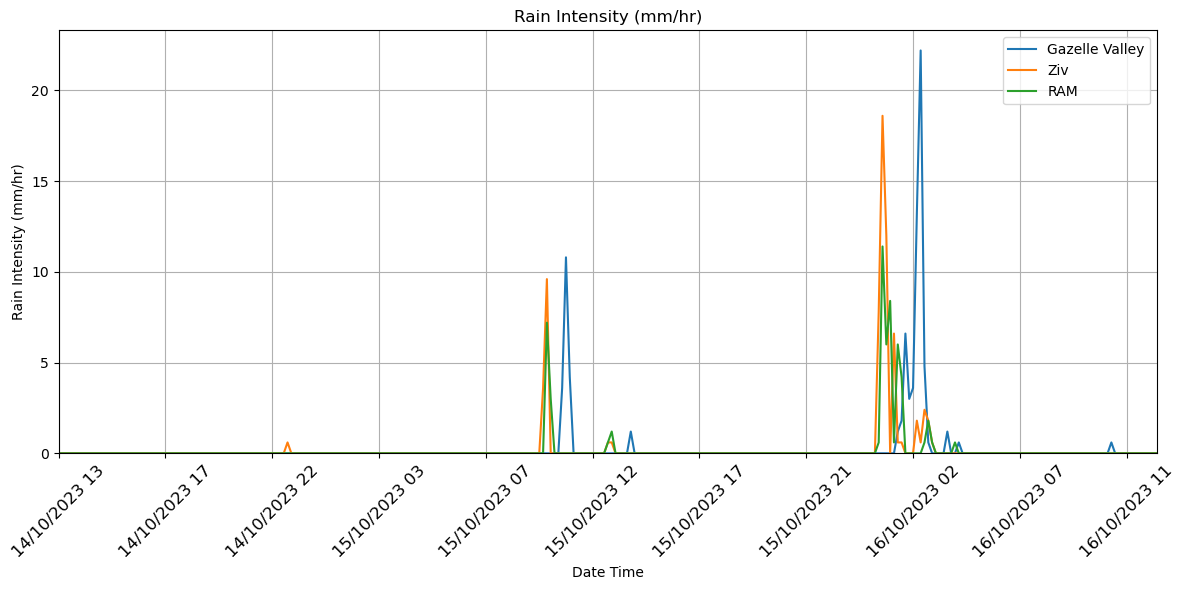

In [10]:
plot_rain_intensity([gv_rain_df, ziv_rain_df, ram_rain_df], '14/10/2023 13:00', '16/10/2023 13:00')

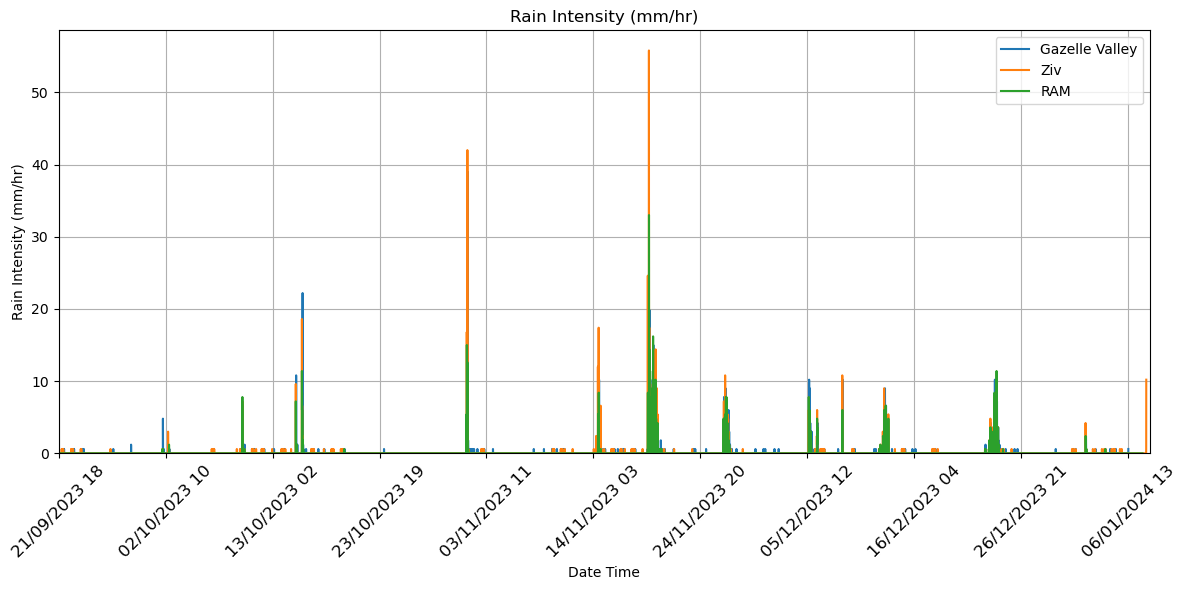

In [11]:
plot_rain_intensity([gv_rain_df, ziv_rain_df, ram_rain_df], '21/09/2023 18:00', '08/01/2024 18:00')


## Cumulative Rain

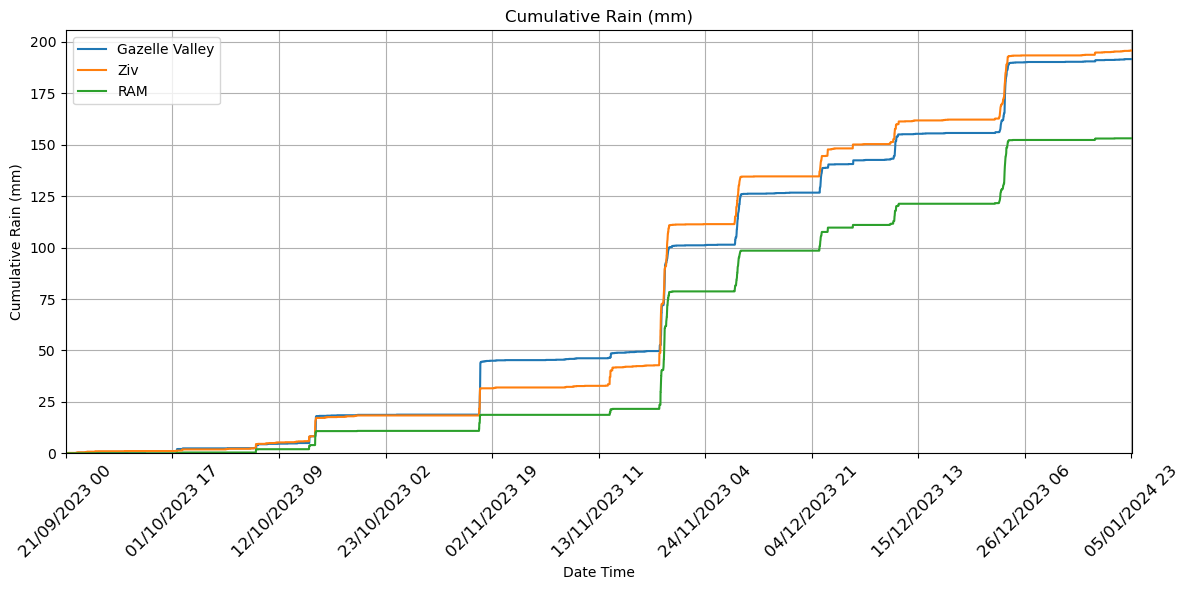

In [12]:
plot_cumulative_rain([gv_rain_df, ziv_rain_df, ram_rain_df], '21/09/2023 00:30', '06/01/2024 00:00')

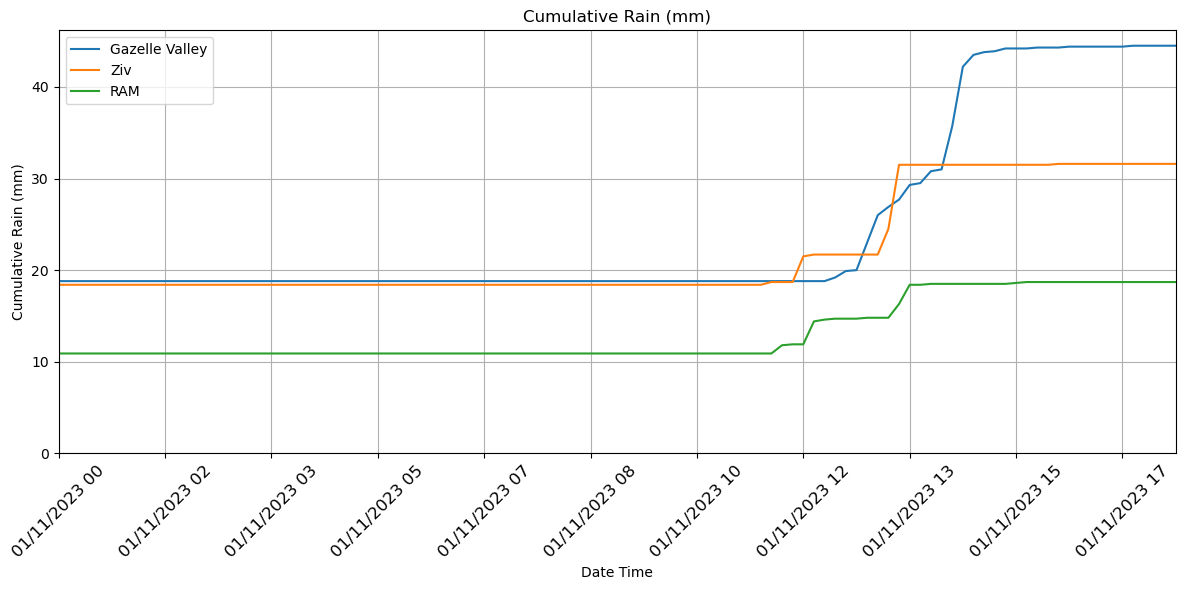

In [15]:
plot_cumulative_rain([gv_rain_df, ziv_rain_df, ram_rain_df], '01/11/2023 00:30', '01/11/2023 18:00')